In [12]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from algorithms import Prox
from spaces import SymmetricPositiveDefinite

space = SymmetricPositiveDefinite(dimension=3, metric= "AIRM")
S = space.sample(n_samples=20, seed=0, dtype=np.float64)
prox = Prox(space=space)
taus = [0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
means = []
sequences = []
for t in taus:
    fm, x_seq = prox.Frechet_mean(S[0], S, method = "relaxed", 
                            tau= t, 
                            tol=1e-13, max_iter=500,
                            show_progress = True)
    means.append(fm)
    sequences.append(x_seq)                        

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:11<00:00, 43.78it/s]


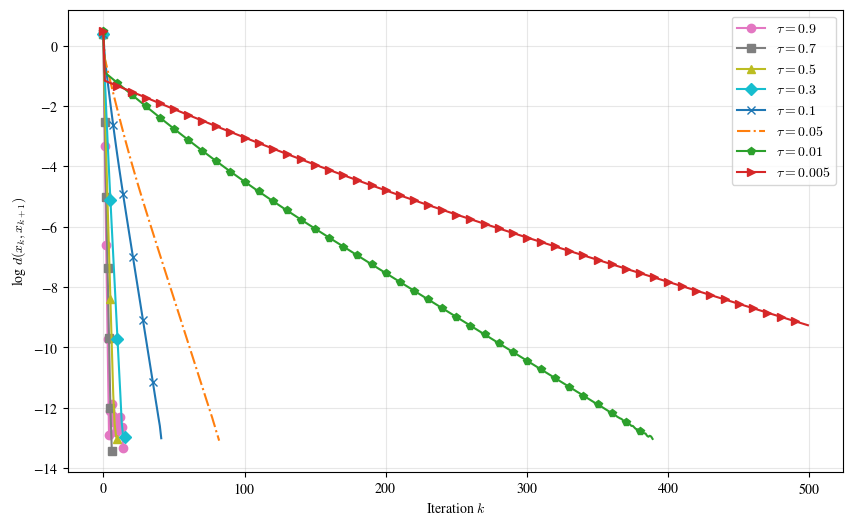

In [2]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['no-latex'])  # no-latex avoids LaTeX dependency



styles = ["-o", "-s", "-^", "-D", "-x", "-.", "-p", "->"]        
colors = [f"C{i+6}" for i in range(len(taus)+10)] 
#colors = plt.cm.Blues(np.linspace(0.9, 0.2, len(taus)))  # avoid too-white and too-dark 
freq = [1, 1, 5, 5, 7, 10, 10,10]
plt.figure(figsize=(10,6))       
for i in range(len(sequences)):
    outer_seq = [x[-1] for x in sequences[i]]
    distances = [np.log10(space.dist(outer_seq[j], outer_seq[j+1])) for j in range(len(outer_seq)-1)]
    plt.plot(distances, styles[i], color=colors[i], markevery=freq[i], label=rf'$\tau={taus[i]}$')


plt.xlabel(r'Iteration $k$')
plt.ylabel(r'log $d(x_{k} , x_{k+1})$')
#plt.title('Convergence of SPD iterates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/SPD_iterates.png", 
#bbox_inches="tight",
#dpi=1000
#)

In [4]:
# sorted samples without diameter bound to see the lower and upper bound of diameters. 
D = []
for d in range(100):
    space = SymmetricPositiveDefinite(dimension=3, metric= "AIRM")
    S = space.sample(n_samples=20, seed=int(np.random.SeedSequence().entropy)% (2**32), dtype=np.float64)
    prox = Prox(space=space)
    D.append(space.diameter(S)[0])


print(np.sort(D))   

[ 6.54184226  8.16374366  8.39932597  8.68526672  8.6964008   8.95091832
  9.36608071  9.46214633  9.57815202  9.62789721  9.71455208 10.12590079
 10.20504697 10.47852202 10.50140749 10.50907527 10.66159087 10.67302628
 10.96128883 11.10324218 11.22840343 11.2650573  11.28544683 11.38682548
 11.40317578 11.49040454 11.64253853 11.68465039 11.73262384 11.85796084
 11.88945719 11.97926342 12.00442576 12.02240052 12.08945553 12.11104749
 12.12820687 12.14136469 12.16538265 12.30222083 12.46537223 12.471514
 12.57840093 12.73810354 12.77968353 12.90406839 12.91779752 13.10302369
 13.12564408 13.25386265 13.3055141  13.31394687 13.34220691 13.41140507
 13.50260802 13.58845337 13.78372557 13.88148764 13.88850033 13.92156794
 14.00201516 14.01340416 14.06010577 14.08220237 14.13594234 14.15826696
 14.32882047 14.37654954 14.50077584 14.75001769 14.87162269 14.91770897
 14.95578498 14.981573   14.99790076 15.28973799 15.34579814 15.39564972
 15.56359156 15.58313902 15.7074285  15.77298301 15.7

Sample diameter:  10.646310573948393
  step length    diameter    {step length/diameter}
-------------  ----------  ------------------------
        0.9     3.60953                    0.24934
        0.7     2.90054                    0.241334
        0.5     2.10078                    0.238007
        0.3     1.22773                    0.244354
        0.1     0.412584                   0.242375
        0.05    0.207207                   0.241305
        0.01    0.0414481                  0.241266
        0.005   0.0207201                  0.241312


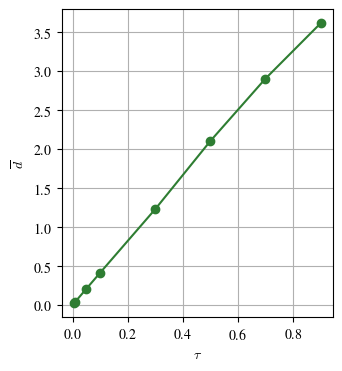

In [14]:
#example of comparing final diameter and step length for one sample
import matplotlib.pyplot as plt
from tabulate import tabulate
S = space.sample(n_samples=20, seed=0, dtype=np.float64)
sample_d, _ = space.diameter(S)
print("Sample diameter: ", sample_d)
taus = [0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
diams = [space.diameter(s[-1])[0] for s in sequences]
ratios = [taus[i]/diams[i] for i in range(len(diams))]
plt.figure(figsize=(3.5,4))
plt.plot(taus, diams, marker='o',color='#2e7d32' )
#plt.plot(taus, ratios, marker='o', color='#7b1fa2')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\overline{d}$')
#plt.title('Comparing final diameter and step length')
plt.grid(True)
#plt.show()
plt.savefig(
    "/Users/mahshid/Documents/git/treespace/Mahshid/Latex/images/spd_ratio.png",
    bbox_inches="tight",
    dpi=1000
)   

rows = list(zip(taus, diams, ratios))
print(tabulate(rows, headers=["step length", "diameter", "{step length/diameter}"]))

In [16]:
# produce the whole data first and then compute subsets in each diameter, centered at the first random data
import matplotlib.pyplot as plt
from tabulate import tabulate
import tqdm
space = SymmetricPositiveDefinite(dimension=4, metric= "AIRM")
data_diam = [5, 7, 10, 15, 20, 23, 25, 30, 35]
taus = [0.99, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
results = []  # store everything: {"d":..., "sample_d":..., "diams":..., "ratios":...}

# --------- compute once ----------
for d in tqdm.tqdm(data_diam):

    S = space.sample(n_samples=50, seed=0, diam=d, dtype=np.float64)
    sample_d, _ = space.diameter(S)
    sequences = []
    for t in taus:
        fm, x_seq = prox.Frechet_mean(
            S[0], S, method="relaxed",
            tau=t, tol=1e-16, max_iter=500
        )
        sequences.append(x_seq)

    diams  = [space.diameter(s[-1])[0] for s in sequences]
    ratios = [taus[i] / diams[i] for i in range(len(taus))]

    results.append({"d": d, "sample_d": sample_d, "diams": diams, "ratios": ratios})


100%|██████████| 9/9 [34:45<00:00, 231.68s/it]


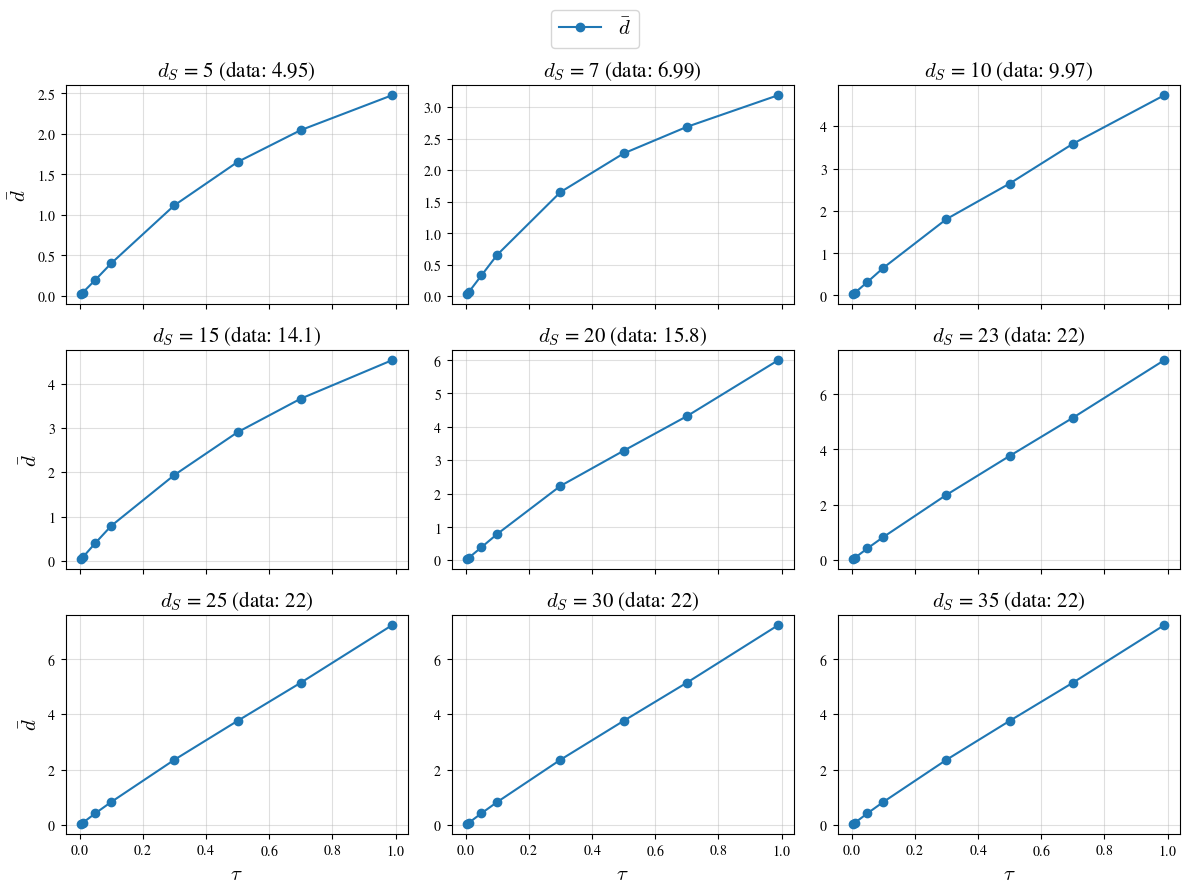

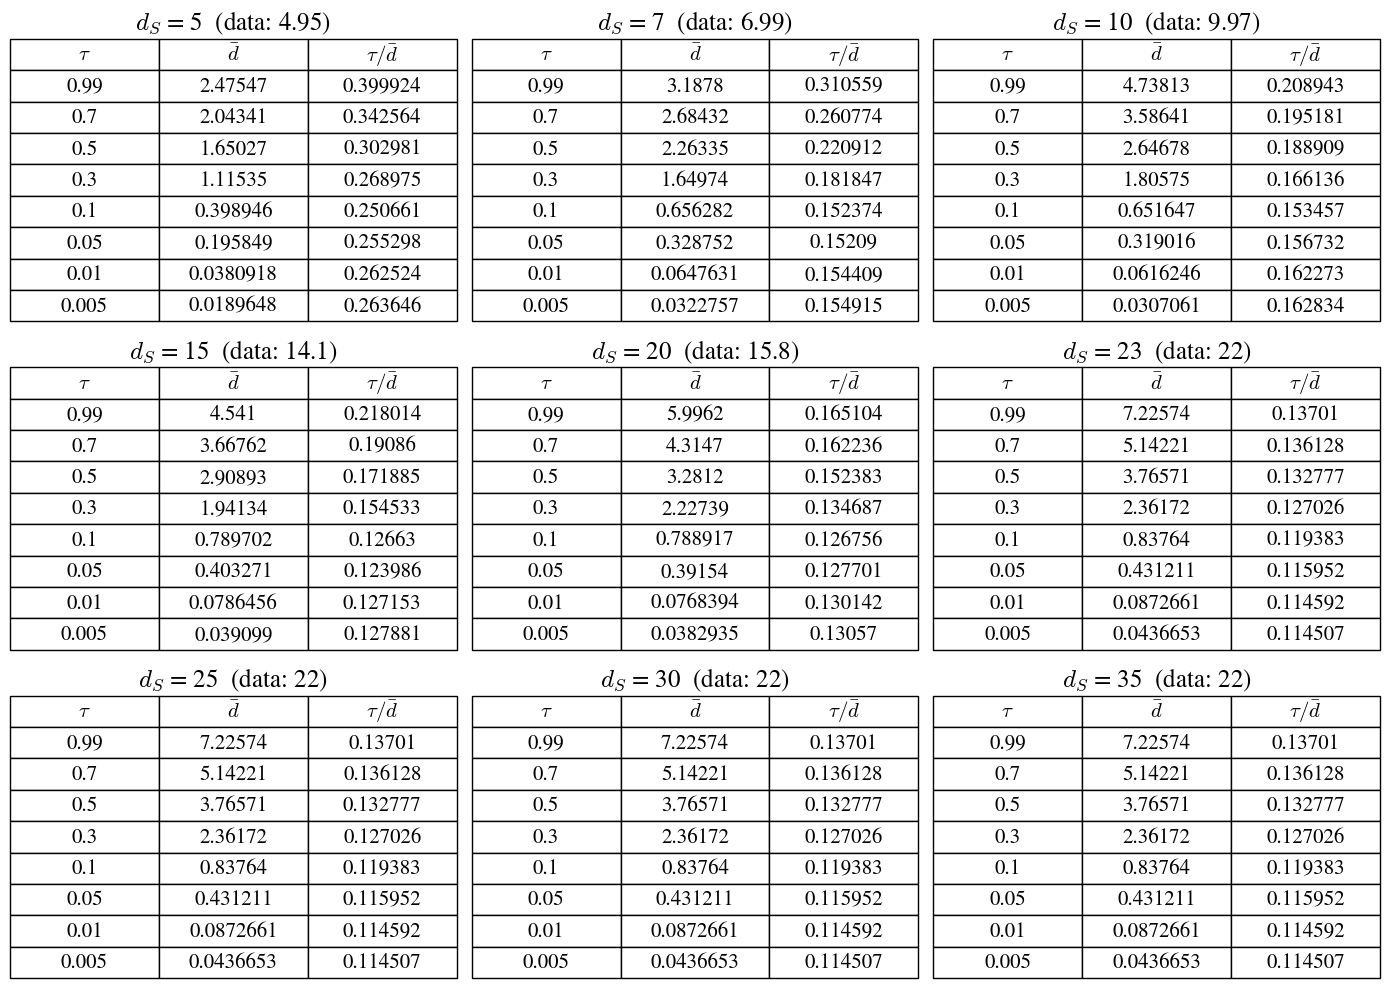

In [19]:

# --------- figure 1: 3x3 plots ----------
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True)
axes = axes.ravel()


for i, r in enumerate(results):
    ax = axes[i]
    ax.plot(taus, r["diams"], marker="o", label=r"$\bar{d}$")
    #ax.plot(taus, r["ratios"], marker="o", label=r"$\tau/\bar{d}$")
    ax.grid(True, alpha=0.4)
    ax.set_title(fr"$d_S$ = {r['d']} (data: {r['sample_d']:.3g})", fontsize=15)

for ax in axes[6:]:
    ax.set_xlabel(r"$\tau$", fontsize=15)
for ax in axes[0::3]:
    ax.set_ylabel(r"$\bar{d}$", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_plot.png", bbox_inches="tight")
plt.show()

# --------- figure 2: 3x3 tables ----------
figT, axesT = plt.subplots(3, 3, figsize=(14, 10))
axesT = axesT.ravel()

col_labels = [r"$\tau$", r"$\bar{d}$", r"$\tau/\bar{d}$"]


for i, r in enumerate(results):
    ax = axesT[i]
    ax.axis("off")
    ax.set_title(fr"$d_S$ = {r['d']}  (data: {r['sample_d']:.3g})", fontsize=18)

    # format numbers nicely
    cell_text = [
        [f"{taus[j]:.3g}", f"{r['diams'][j]:.6g}", f"{r['ratios'][j]:.6g}"]
        for j in range(len(taus))
    ]

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(15)
    tbl.scale(1, 1.5)  # (scale on width, scale on height) 

figT.tight_layout()
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_table.png", bbox_inches="tight")

plt.show()
